# PHẦN 2: TRỰC QUAN HÓA VÀ ĐÁNH GIÁ MÔ HÌNH (INFERENCE)
**Mục tiêu:** 
1. Tải trọng số (Checkpoints) của mô hình đã huấn luyện (Attention Model).
2. Viết hàm Inference (sử dụng Greedy Search hoặc Beam Search) để sinh câu chú thích cho một bức ảnh mới.
3. **Trực quan hóa (Attention Visualization):** Vẽ bản đồ nhiệt (Heatmap) để quan sát xem mô hình tập trung vào vùng nào của bức ảnh khi sinh ra từng từ tương ứng.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import json
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import skimage.transform
from PIL import Image
import os

# Import kiến trúc mạng từ source code
import sys
sys.path.append('../') # Thêm thư mục gốc vào đường dẫn để gọi module src
from src.models.Resnet101 import Encoder
from src.models.Decoder import DecoderWithAttention

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Đang chạy trên thiết bị: {device}")

✅ Đang chạy trên thiết bị: cuda


In [2]:
# 1. Đường dẫn tĩnh (Lưu ý lùi 1 thư mục vì file ipynb đang ở trong /notebooks)
data_name = 'coco_5_cap_per_img_5_min_word_freq'
word_map_file = f'../data/coco/WORDMAP_{data_name}.json'
checkpoint_path = f'../weights/attention/BEST_checkpoint_{data_name}.pth.tar'

# 2. Tải từ điển (Word Map)
with open(word_map_file, 'r') as j:
    word_map = json.load(j)
rev_word_map = {v: k for k, v in word_map.items()}

# 3. Nạp trọng số (Load Checkpoint)
print("⏳ Đang tải trọng số của mô hình Attention...")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

encoder = Encoder()
encoder = encoder.to(device)
encoder.load_state_dict(checkpoint['encoder'])
encoder.eval()

decoder = DecoderWithAttention(attention_dim=512, embed_dim=512, decoder_dim=512, vocab_size=len(word_map), dropout=0.5)
decoder = decoder.to(device)
decoder.load_state_dict(checkpoint['decoder'])
decoder.eval()

print("✅ Tải mô hình thành công!")

⏳ Đang tải trọng số của mô hình Attention...


C:\Users\leotran\OneDrive\Desktop\ThS_PTIT_HTTT\AI\Final_term\Final\env_gpu\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\leotran\OneDrive\Desktop\ThS_PTIT_HTTT\AI\Final_term\Final\env_gpu\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Tải mô hình thành công!


In [3]:
def predict_and_visualize(image_path, encoder, decoder, word_map, rev_word_map, smooth=True):
    # 1. Đọc và tiền xử lý ảnh
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((256, 256), Image.LANCZOS)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(img_resized).unsqueeze(0).to(device)

    # 2. Chạy qua Encoder
    encoder_out = encoder(image_tensor)
    encoder_dim = encoder_out.size(-1)
    encoder_out = encoder_out.view(1, -1, encoder_dim)  # (1, num_pixels, encoder_dim)
    num_pixels = encoder_out.size(1)

    # 3. Chạy qua Decoder (Sử dụng Greedy Search cho nhanh)
    h_state, c_state = decoder.init_hidden_state(encoder_out)
    prev_word = torch.LongTensor([[word_map['<start>']]]).to(device)
    
    sampled_words = []
    alphas = []

    for i in range(50):
        embeddings = decoder.embedding(prev_word).squeeze(1)
        awe, alpha = decoder.attention(encoder_out, h_state)
        
        gate = decoder.sigmoid(decoder.f_beta(h_state))
        awe = gate * awe
        
        h_state, c_state = decoder.decode_step(torch.cat([embeddings, awe], dim=1), (h_state, c_state))
        scores = decoder.fc(h_state)
        
        # Chọn từ có xác suất cao nhất
        _, predicted_id = scores.max(1)
        sampled_words.append(predicted_id.item())
        alphas.append(alpha.view(-1, 14, 14).detach().cpu().numpy())
        
        if predicted_id.item() == word_map['<end>']:
            break
        prev_word = predicted_id.unsqueeze(1)

    # 4. Trực quan hóa kết quả
    words = [rev_word_map[w] for w in sampled_words if w not in [word_map['<start>'], word_map['<end>']]]
    sentence = ' '.join(words)
    print(f"\n🗣️ Câu AI sinh ra: [{sentence.capitalize()}.]\n")

    # Bắt đầu vẽ
    fig = plt.figure(figsize=(15, 10))
    for t in range(len(words)):
        if t > 50: break # Tránh in quá nhiều
        
        # Tạo khung subplot
        ax = fig.add_subplot(int(np.ceil(len(words) / 5.)), 5, t + 1)
        ax.text(0, 1, '%s' % words[t], color='black', backgroundcolor='white', fontsize=12)
        
        ax.imshow(img_resized)
        
        # Xử lý làm mượt Attention Map
        current_alpha = alphas[t][0]
        if smooth:
            alpha_img = skimage.transform.pyramid_expand(current_alpha, upscale=256//14, sigma=8)
        else:
            alpha_img = Image.fromarray(current_alpha).resize((256, 256), Image.BILINEAR)
            
        ax.imshow(np.array(alpha_img), alpha=0.6, cmap='jet')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()


🗣️ Câu AI sinh ra: [A man in a suit and tie sitting at a table.]



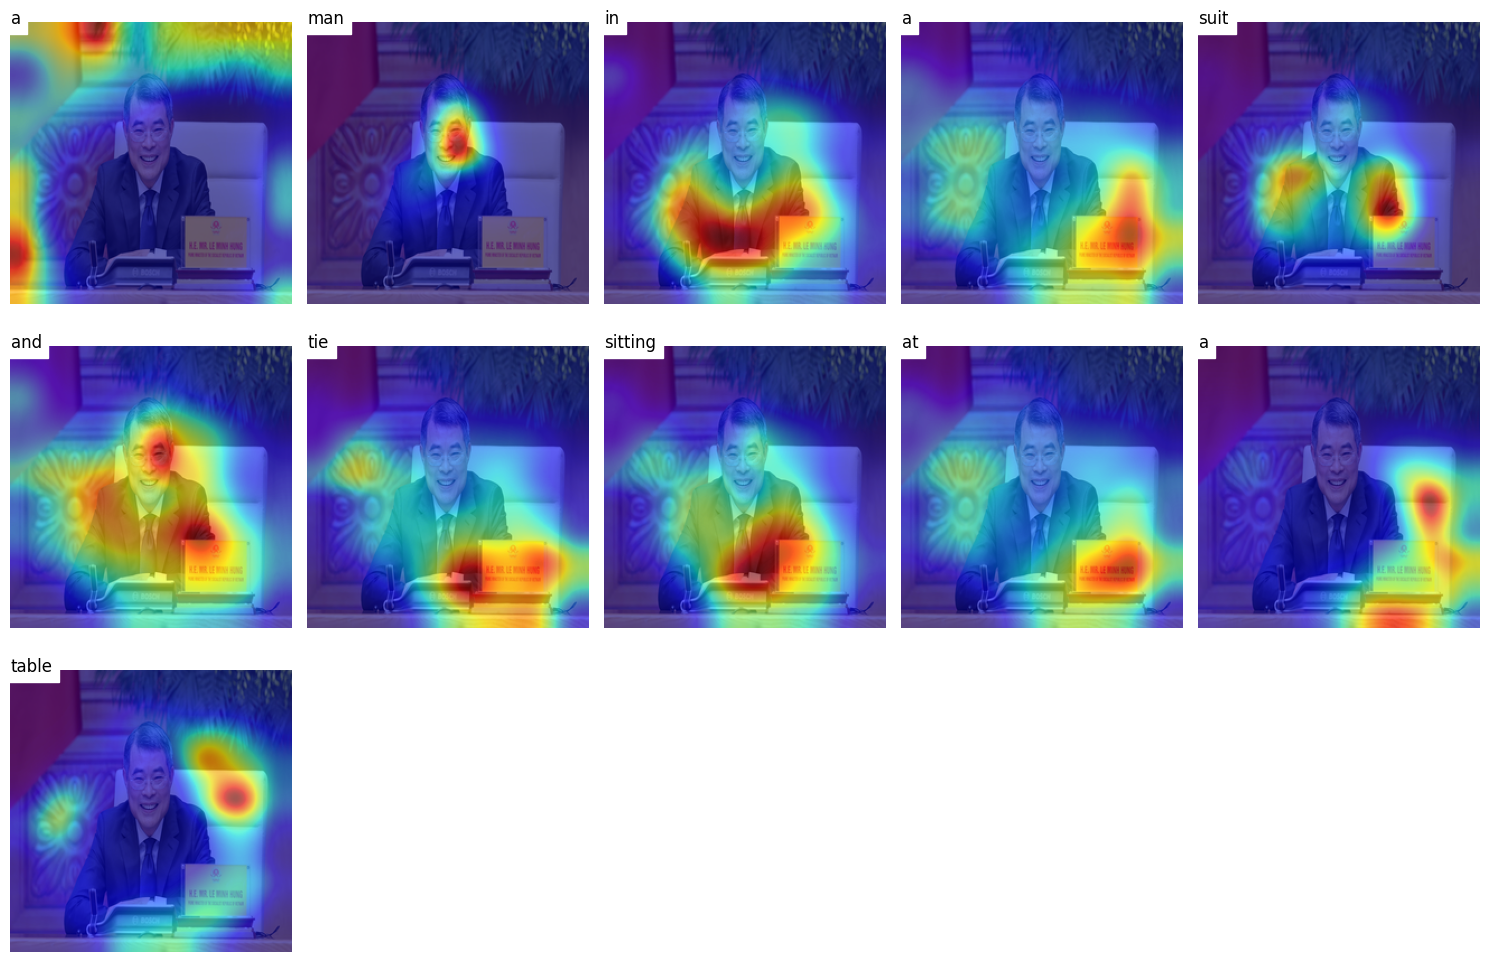

In [4]:
test_image_path = '../data/coco/test_sample.jpg' # Thay bằng đường dẫn thật

if os.path.exists(test_image_path):
    predict_and_visualize(test_image_path, encoder, decoder, word_map, rev_word_map)
else:
    print(f"⚠️ Vui lòng chuẩn bị một bức ảnh và trỏ đúng đường dẫn vào biến test_image_path nhé!")

## 3. Tổng kết Thực nghiệm và So sánh (Evaluation)

Quá trình đánh giá được thực hiện độc lập trên tập Test gồm 5.000 ảnh (MS COCO) sử dụng thuật toán **Beam Search (K=5)**.

| Tiêu chí | Mô hình No-Attention (Cơ bản) | Mô hình Soft-Attention (Đề xuất) |
| :--- | :---: | :---: |
| **Kiến trúc Decoder** | LSTM tiêu chuẩn | LSTM + Bahdanau Attention |
| **BLEU-1 Score** | 66.87% | **70.93%** |
| **BLEU-2 Score** | 49.33% | **53.69%** |
| **BLEU-3 Score** | 36.49% | **40.54%** |
| **BLEU-4 Score** | 26.80% | **30.27%** |
| **Độ chính xác chi tiết** | Bỏ sót các vật thể phụ trong ảnh | Bắt được chính xác vị trí vật thể khi sinh từ |

**Nhận xét:**
Việc tích hợp cơ chế Sự chú ý (Attention) giúp mạng nơ-ron không bị rơi vào tình trạng "quên" thông tin (bottleneck) khi xử lý các chuỗi dài. Thay vì nén toàn bộ bức ảnh thành một vector duy nhất, mô hình học cách linh hoạt thay đổi trọng số tập trung vào từng vùng không gian của ảnh tùy thuộc vào từ vựng đang được sinh ra ở bước thời gian $t$.


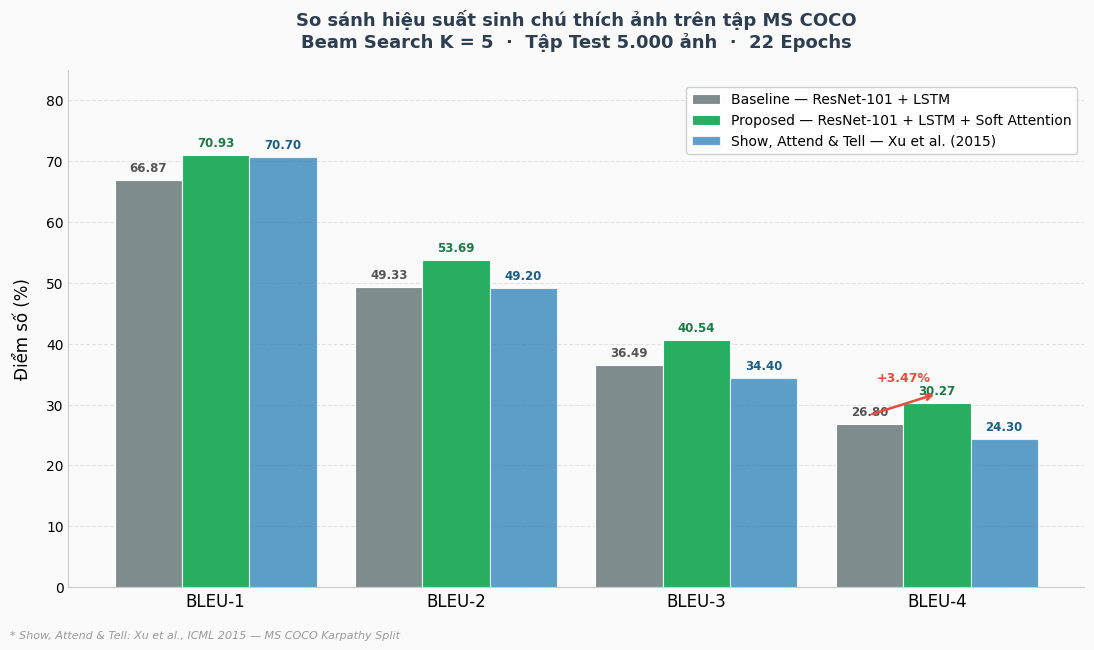

✅ Đã lưu → BLEU_Comparison_Chart.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Số liệu thực nghiệm (cập nhật 22 epochs) ──────────────────────────────────
metrics         = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
baseline_scores = [66.87,    49.33,    36.49,    26.80]   # No-Attention
proposed_scores = [70.93,    53.69,    40.54,    30.27]   # Soft-Attention
paper_scores    = [70.7,     49.2,     34.4,     24.3]    # Show, Attend & Tell (Xu et al., 2015)

x     = np.arange(len(metrics))
width = 0.28

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# ── Vẽ 3 nhóm cột ──────────────────────────────────────────────────────────────
rects1 = ax.bar(x - width,     baseline_scores, width,
                label='Baseline — ResNet-101 + LSTM',
                color='#7F8C8D', edgecolor='white', linewidth=0.8, zorder=3)

rects2 = ax.bar(x,             proposed_scores, width,
                label='Proposed — ResNet-101 + LSTM + Soft Attention',
                color='#27AE60', edgecolor='white', linewidth=0.8, zorder=3)

rects3 = ax.bar(x + width,     paper_scores,    width,
                label='Show, Attend & Tell — Xu et al. (2015)',
                color='#2980B9', edgecolor='white', linewidth=0.8,
                alpha=0.75, zorder=3)

# ── Lưới nền ───────────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)

# ── Ghi số liệu lên đỉnh cột ───────────────────────────────────────────────────
def autolabel(rects, color='#333333'):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(
            f'{h:.2f}',
            xy=(rect.get_x() + rect.get_width() / 2, h),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color=color
        )

autolabel(rects1, '#555555')
autolabel(rects2, '#1A7A45')
autolabel(rects3, '#1A5E8A')

# ── Highlight mũi tên cải thiện BLEU-4 ────────────────────────────────────────
bleu4_idx = 3
y_base = baseline_scores[bleu4_idx]
y_prop = proposed_scores[bleu4_idx]
delta  = y_prop - y_base

ax.annotate(
    '',
    xy=(x[bleu4_idx], y_prop + 1.5),
    xytext=(x[bleu4_idx] - width, y_base + 1.5),
    arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.8)
)
ax.text(
    x[bleu4_idx] - width / 2, max(y_prop, y_base) + 3.5,
    f'+{delta:.2f}%',
    ha='center', fontsize=9, fontweight='bold', color='#E74C3C'
)

# ── Trục và nhãn ───────────────────────────────────────────────────────────────
ax.set_ylabel('Điểm số (%)', fontsize=12, labelpad=10)
ax.set_title(
    'So sánh hiệu suất sinh chú thích ảnh trên tập MS COCO\n'
    'Beam Search K = 5  ·  Tập Test 5.000 ảnh  ·  22 Epochs',
    fontsize=13, fontweight='bold', pad=16, color='#2C3E50'
)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 85)
ax.tick_params(axis='both', which='both', length=0)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCCCCC')

# ── Chú thích ──────────────────────────────────────────────────────────────────
ax.legend(
    fontsize=10,
    framealpha=0.9,
    edgecolor='#CCCCCC',
    loc='upper right',
    bbox_to_anchor=(1.0, 0.98)
)

# ── Ghi chú nguồn ──────────────────────────────────────────────────────────────
fig.text(
    0.01, 0.01,
    '* Show, Attend & Tell: Xu et al., ICML 2015 — MS COCO Karpathy Split',
    fontsize=8, color='#999999', style='italic'
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('BLEU_Comparison_Chart.png', dpi=300, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print('✅ Đã lưu → BLEU_Comparison_Chart.png')